In [67]:
using Pkg
Pkg.activate("/Users/jose/Documents/Works/MIT/RaX/Simu/Molecule-Sims/")

  Activating project at `~/Documents/Works/MIT/RaX/Simu/Molecule-Sims`


In [68]:
using Revise

In [69]:
using Distributed
procs_to_use = 1

if nprocs() <= procs_to_use
    addprocs(procs_to_use-nprocs())
end

@everywhere using
    QuantumStates,
    OpticalBlochEquations,
    Logging,
    TerminalLoggers,
    DifferentialEquations,
    UnitsToValue,
    LinearAlgebra,
    Printf,
    Plots,
    Random,
    StatsBase,
    Distributions,
    StructArrays,
    StaticArrays,
    StructArrays,
    LoopVectorization,
    Parameters,
    MutableNamedTuples

@everywhere @consts begin
    λ = 552e-9
    Γ = 2π * 5.7e6
    m = @with_unit 191 "u"
    k = 2π / λ
    _μB = (μB / h) * 1e-4
    kB = 1.380649e-23
end
;

In [70]:
P = 2.5 * 13.6 # power in mW, converting from voltage (1 V = 13.6 mW)
detunning = -6.

-6.0

### Calculate transition dipole moments

In [71]:
@everywhere begin
    include("define_states.jl")
    X_states, A_states = define_YbF_states(10.0*10^-4)
    states = [X_states; A_states]
    d = tdms_between_states(states, states)
end
;

  Activating project at `~/Documents/Works/MIT/RaX/Simu/Molecule-Sims`


### Define lasers

In [72]:
CONFIGURATION = "XY_parallel"
g_interest_states = [state for state in X_states][1:4]
input_energies = [energy(st) for st in g_interest_states]
# Target states
a_qns =[extract_quantum_numbers_from_state(st) for st in A_states][1]
energies = [energy(st) for st in A_states]
# sorted
target_states = sort(A_states, by = energy)
target_energy = [energy(st) for st in A_states][1]
A_energy = target_energy
δJ12 = detunning * Γ
ω_J12s = [2π * (A_energy - inp_e) + δJ12 for inp_e in input_energies]
s_func(s) = (r,t) -> s
s_J12 = s_func(100.0)
ratios = [1, 1/2, 1/2, 0]
s_J12_sidebands = [s_func(ratio * 100.0) for ratio in ratios]


4-element Vector{var"#341#342"{Float64}}:
 #341 (generic function with 1 method)
 #341 (generic function with 1 method)
 #341 (generic function with 1 method)
 #341 (generic function with 1 method)

In [73]:
@everywhere sim_params = MutableNamedTuple(
    pol_imbalance = 0.0,
    s_imbalance = (0.0, 0.0, 0.0),
    retro_loss = 0.0,
    off_center = (0, 0, 0, 0, 0, 0) .* 1e-3,
    pointing_error = (0,0,0,0,0,0),
    photon_budget=Inf,
    RF_frequency = 2π * 14e6 / Γ,
    B_gradient = +1. * 1e-4,
    B_offset = (1. , 1., 1. ) .* 1e-4,
)



In [74]:
@everywhere begin
    include("define_lasers.jl")
    lasers_XY_parallel, lasers_XY_perpendicular = generate_lasers(
CONFIGURATION, σ⁺, ω_J12s, s_J12_sidebands
    )
end
;

### Define Zeeman Hamiltonian

In [75]:
@everywhere include("define_zeeman_hamiltonian.jl")
;

# Run simulation

In [76]:
lasers = lasers_XY_parallel

16-element Vector{Field{Float64, var"#345#364"{SVector{3, ComplexF64}}, var"#341#342"{Float64}}}:
 Field{Float64, var"#345#364"{SVector{3, ComplexF64}}, var"#341#342"{Float64}}([1.0, 0.0, 0.0], var"#345#364"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im]), ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im], 3.667653047691414e15, var"#341#342"{Float64}(100.0), 0.0, 0.0, 0.0, 0.0, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])
 Field{Float64, var"#345#364"{SVector{3, ComplexF64}}, var"#341#342"{Float64}}([1.0, 0.0, 0.0], var"#345#364"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im]), ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im], 3.667653047691414e15, var"#341#342"{Float64}(50.0), 0.0, 0.0, 0.0, 0.0, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])
 Field{Float64, var"#345#364"{SVector{3, ComplexF64}}, var"#341#342"{Float64}}([1.0, 0.0, 0.0], var"#345#364"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0i

In [77]:
@everywhere function update_H_and_∇H(H, p, r, t)

    # Define a ramping magnetic field
    Zeeman_Hz = p.extra_data.Zeeman_Hz
    Zeeman_Hx = p.extra_data.Zeeman_Hx
    Zeeman_Hy = p.extra_data.Zeeman_Hy

    scalar = cos(sim_params.RF_frequency * t + π/2)

    gradient_x = -scalar * p.sim_params.B_gradient * 1e2 / k / 2
    gradient_y = +scalar * p.sim_params.B_gradient * 1e2 / k / 2
    gradient_z = -scalar * p.sim_params.B_gradient * 1e2 / k

    Bx = gradient_x * r[1] + p.sim_params.B_offset[1]
    By = gradient_y * r[2] + p.sim_params.B_offset[2]
    Bz = gradient_z * r[3] + p.sim_params.B_offset[3]

    @turbo for i in eachindex(H)
        H.re[i] = Bz * Zeeman_Hz.re[i] + Bx * Zeeman_Hx.re[i] + By * Zeeman_Hy.re[i]
        H.im[i] = Bz * Zeeman_Hz.im[i] + Bx * Zeeman_Hx.im[i] + By * Zeeman_Hy.im[i]
    end

    ∇H = SVector{3, Float64}(0,0,0)

    return ∇H
end
;

In [78]:
@everywhere extra_data = MutableNamedTuple(
    Zeeman_Hx = Zeeman_x_mat,
    Zeeman_Hy = Zeeman_y_mat,
    Zeeman_Hz = Zeeman_z_mat
)
;

In [79]:
@everywhere begin
    t_start = 0.0
    t_end   = 1e-1
    t_span  = (t_start, t_end) ./ (1/Γ)

    n_states = length(states)
    n_excited = 4

    r0 = [0, 0, 0.]
    v0 = [0.1, 0.1, 1]
    particle = Particle()
    particle.r = r0 ./ (1/k)
    particle.v = v0 ./ (Γ/k)
    ψ₀ = zeros(ComplexF64, n_states)
    ψ₀[1] = 1.0
end

global_logger(TerminalLogger())

p = schrodinger_stochastic(particle, states, lasers, d, ψ₀, m/(ħ*k^2/Γ), n_excited; sim_params=sim_params, extra_data=extra_data, λ=λ, Γ=Γ, update_H_and_∇H=update_H_and_∇H)

prob = ODEProblem(ψ_stochastic_potential!, p.ψ, t_span, p)

cb = ContinuousCallback(condition, SE_collapse_pol_always!, nothing, save_positions=(false,false))
@time sol = DifferentialEquations.solve(prob, alg=DP5(), reltol=1e-3, callback=cb, saveat=1000, maxiters=80000000, progress=true, progress_steps=200000)
;

ODE   0%|                                               |  ETA: N/A


  6.200870 seconds (25.53 M allocations: 787.119 MiB, 4.44% gc time, 68.52% compilation time)


ODE 100%|███████████████████████████████████████████████| Time: 0:00:01


In [80]:
plot_us = sol.u
plot_ts = sol.t
x_trajectories = [real(u[n_states + n_excited + 1]) for u in plot_us]./k*1e3
y_trajectories = [real(u[n_states + n_excited + 2]) for u in plot_us]./k*1e3
z_trajectories = [real(u[n_states + n_excited + 3]) for u in plot_us]./k*1e3
x_velocities = [real(u[n_states + n_excited + 4]) for u in plot_us] .* (Γ/k)
y_velocities = [real(u[n_states + n_excited + 5]) for u in plot_us] .* (Γ/k)
z_velocities = [real(u[n_states + n_excited + 6]) for u in plot_us] .* (Γ/k)
velocities = [[vx,vy,vz] for (vx,vy,vz) ∈ zip(x_velocities, y_velocities, z_velocities)]

excited_population = real.([sum(conj(u[i]) * u[i] for i ∈ 13:16) for u in plot_us])
;

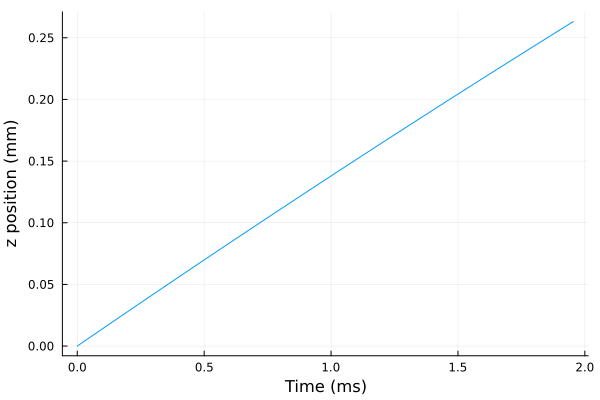

In [81]:
plot(sol.t .* (1e3/Γ), (x_trajectories .+ y_trajectories) ./ √2,
    legend=nothing,
    xlabel="Time (ms)",
    ylabel="z position (mm)",
)

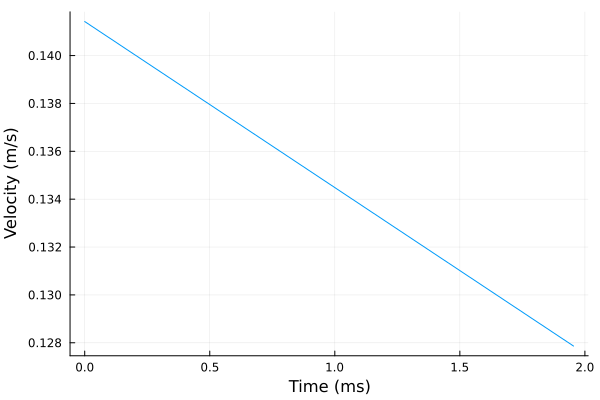

In [82]:
plot(sol.t .* (1e3/Γ), (x_velocities .+ y_velocities) /√2,
    legend=nothing,
    xlabel="Time (ms)",
    ylabel="Velocity (m/s)"
)

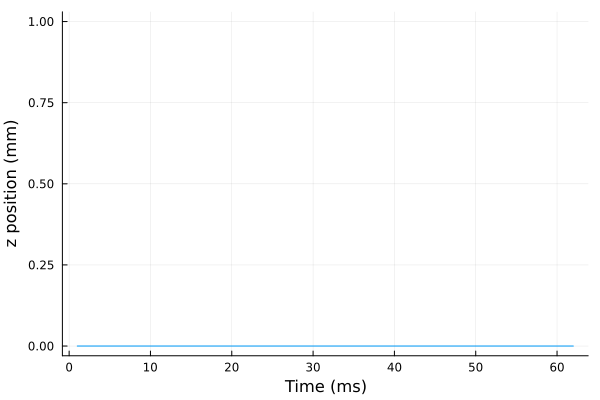

In [83]:
moving_average(vs,n) = [sum(@view vs[i:(i+n-1)])/n for i in 1:(length(vs)-(n-1))]

plot(moving_average(Γ * excited_population, 10),
    legend=nothing,
    xlabel="Time (ms)",
    ylabel="z position (mm)",
)

In [84]:
prob.p.n_scatters * 0.011 / √2

0.0

### Run simulation for multiple particles in parallel

In [85]:
@everywhere function prob_func(prob, i, repeat)

     lasers = define_lasers(
        states,
        sim_params.RF_frequency,
        sim_params.s1,
        sim_params.s2,
        sim_params.s3,
        sim_params.s4,
        sim_params.Δ1,
        sim_params.Δ2,
        sim_params.Δ3,
        sim_params.Δ4,
        sim_params.pol1_x,
        sim_params.pol2_x,
        sim_params.pol3_x,
        sim_params.pol4_x,
        sim_params.pol_imbalance,
        sim_params.s_imbalance,
        sim_params.retro_loss,
        sim_params.off_center,
        sim_params.pointing_error
    )

    # Define initial conditions for the molecule
    cloud_size = @with_unit 0.5 "mm"
    particle = Particle()
    particle.r = (rand(Normal(0, cloud_size)), rand(Normal(0, cloud_size)), rand(Normal(0, cloud_size))) ./ (1/k)

    ψ₀ = zeros(ComplexF64, n_states)
    ψ₀[1] = 1.0

    p = schrodinger_stochastic(particle, states, lasers, d, ψ₀, m/(ħ*k^2/Γ), n_excited; sim_params=sim_params, extra_data=extra_data, λ=λ, Γ=Γ, update_H_and_∇H=update_H_and_∇H)

    callback = ContinuousCallback(condition, SE_collapse_pol_always!, nothing, save_positions=(false,false))

    prob = ODEProblem(ψ_stochastic_potential!, p.ψ, t_span, p, callback=callback, reltol=5e-4, saveat=4000, maxiters=80000000)

    return prob
end
;

In [86]:
ensemble_prob = EnsembleProblem(prob; prob_func=prob_func)
;

In [87]:
n_molecules = 100
@time ensemble_sol = solve(ensemble_prob, DP5(), EnsembleDistributed(); trajectories=n_molecules)
;

CapturedException: type NamedTuple has no field s1
Stacktrace:
 [1] getproperty(mnt::MutableNamedTuple{(:pol_imbalance, :s_imbalance, :retro_loss, :off_center, :pointing_error, :photon_budget, :RF_frequency, :B_gradient, :B_offset), Tuple{Base.RefValue{Float64}, Base.RefValue{Tuple{Float64, Float64, Float64}}, Base.RefValue{Float64}, Base.RefValue{NTuple{6, Float64}}, Base.RefValue{NTuple{6, Int64}}, Base.RefValue{Float64}, Base.RefValue{Float64}, Base.RefValue{Float64}, Base.RefValue{Tuple{Float64, Float64, Float64}}}}, s::Symbol)
   @ MutableNamedTuples ~/.julia/packages/MutableNamedTuples/3r0U8/src/MutableNamedTuples.jl:27
 [2] prob_func(prob::ODEProblem{Vector{ComplexF64}, Tuple{Float64, Float64}, true, MutableNamedTuple{(:H, :H₀, :∇H, :ψ, :dψ, :ψ_soa, :dψ_soa, :ω, :eiωt, :Js, :states, :fields, :r0, :r, :v, :d, :d_nnz, :λ, :k, :Γ, :E, :E_k, :ds, :ds_state1, :ds_state2, :sim_params, :extra_data, :mass, :update_H_and_∇H, :populations, :n_scatters, :save_counter, :n_states, :n_ground,

In [88]:
x_trajectories = Array{Vector{Float64}}(fill([],n_molecules))
y_trajectories = Array{Vector{Float64}}(fill([],n_molecules))
z_trajectories = Array{Vector{Float64}}(fill([],n_molecules))
x_velocities = Array{Vector{Float64}}(fill([],n_molecules))
y_velocities = Array{Vector{Float64}}(fill([],n_molecules))
z_velocities = Array{Vector{Float64}}(fill([],n_molecules))
photons_scattered = zeros(n_molecules)

times = Array{Vector{Float64}}(fill([],n_molecules))

for i ∈ 1:n_molecules
    sol_u = ensemble_sol[i].u
    sol_t = ensemble_sol[i].t

    x_trajectories[i] = [x_trajectories[i]; [real(u[n_states + n_excited + 1]) for u in sol_u] ./ k*1e3]
    y_trajectories[i] = [y_trajectories[i]; [real(u[n_states + n_excited + 2]) for u in sol_u] ./ k*1e3]
    z_trajectories[i] = [z_trajectories[i]; [real(u[n_states + n_excited + 3]) for u in sol_u] ./ k*1e3]

    x_velocities[i] = [x_velocities[i]; [real(u[n_states + n_excited + 4]) for u in sol_u] ./ (k/Γ)]
    y_velocities[i] = [y_velocities[i]; [real(u[n_states + n_excited + 5]) for u in sol_u] ./ (k/Γ)]
    z_velocities[i] = [z_velocities[i]; [real(u[n_states + n_excited + 6]) for u in sol_u] ./ (k/Γ)]

    photons_scattered[i] = ensemble_sol[i].prob.p.n_scatters

    times[i] = sol_t .* (1/Γ)
end

trajectories = [
    [[x[1],x[2],x[3]] for x ∈ zip(x_trajectories[i], y_trajectories[i], z_trajectories[i])]
    for i ∈ 1:n_molecules
    ]
;

UndefVarError: UndefVarError: `ensemble_sol` not defined

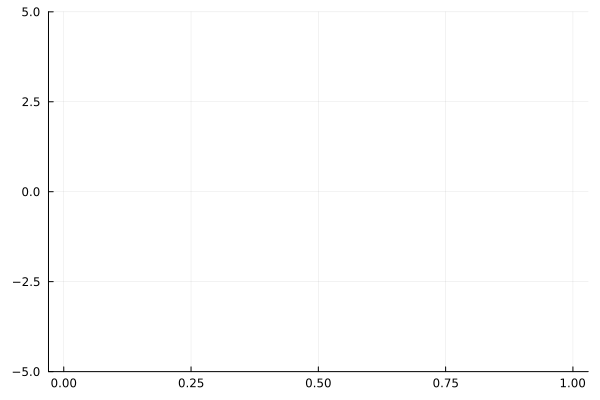

In [89]:
lim = 5
plot()
for i ∈ 1:n_molecules
    plot!(times[i] .* 1e3, z_trajectories[i], legend=nothing, ylim=(-lim, lim))
end
plot!()

In [90]:
function survived(i, t_end, times)
    return t_end ≈ times[i][end]
end

survived_molecules = [survived(i, t_end, times) for i ∈ 1:n_molecules]
survived_x_trajectories = x_trajectories[survived_molecules]
survived_y_trajectories = y_trajectories[survived_molecules]
survived_z_trajectories = z_trajectories[survived_molecules]

survived_x_velocities = x_velocities[survived_molecules]
survived_y_velocities = y_velocities[survived_molecules]
survived_z_velocities = z_velocities[survived_molecules]
;

BoundsError: BoundsError: attempt to access 0-element Vector{Float64} at index [0]

In [91]:
function cloud_size(time, times, x_trajectories, y_trajectories, z_trajectories)
    xs = []
    ys = []
    zs = []
    for i ∈ eachindex(times)
        time_idx = searchsortedfirst(times[i], time)
        if length(times[i]) > time_idx
            push!(xs, x_trajectories[i][time_idx])
            push!(ys, y_trajectories[i][time_idx])
            push!(zs, z_trajectories[i][time_idx])
        end
    end
    return (std(xs) * std(ys) * std(zs))^(1/3)
end

using LsqFit

function Gaussian(x, p)
    σ, x0, A = p
   return A * exp.(-(x.-x0).^2/(2*σ^2))
end

function cloud_size_fitted(xs)

    hist_data = fit(Histogram, xs, -0.2:0.04:0.2)
    hist_data.isdensity = true
    v = collect(hist_data.edges[1])
    dv = v[2]-v[1]
    v = v[1:end-1] .+ dv/2
    fv = hist_data.weights ./ (sum(hist_data.weights) * dv)

    histogram(hist_data)

    v_fit = curve_fit(Gaussian, v, fv, [0.05, 0., 5])
    σ, x0, A = v_fit.param

    display(v_fit.param)
    plot(v, Gaussian(v, v_fit.param))
    histogram!(xs, bins=hist_data.edges, xlim=(-0.2, 0.2), alpha=0.5, normalize=true)

    return σ
end
;

In [92]:
cloud_size_fitted(zs)

UndefVarError: UndefVarError: `zs` not defined

In [93]:
xs = [x_trajectories[i][end] for i ∈ 1:n_molecules]
ys = [y_trajectories[i][end] for i ∈ 1:n_molecules]
zs = [z_trajectories[i][end] for i ∈ 1:n_molecules]

hist_data = fit(Histogram, ys, -0.2:0.01:0.2)
hist_data.isdensity = true
v = collect(hist_data.edges[1])
dv = v[2]-v[1]
v = v[1:end-1] .+ dv/2
fv = hist_data.weights ./ (sum(hist_data.weights) * dv)

v_fit = curve_fit(Gaussian, v, fv, [0.5, 0., 1])
σ, x0, A = v_fit.param

display(v_fit.param)
plot(v, Gaussian(v, v_fit.param))
histogram!(ys, bins=hist_data.edges, xlim=(-0.2, 0.2), alpha=0.5, normalize=true)

BoundsError: BoundsError: attempt to access 0-element Vector{Float64} at index [0]

In [94]:
cloud_sizes = [cloud_size(t,
        times[survived_molecules],
        x_trajectories[survived_molecules],
        y_trajectories[survived_molecules],
        z_trajectories[survived_molecules])
    for t ∈ 0:1e-3:4.9e-3]
;

UndefVarError: UndefVarError: `survived_molecules` not defined

In [95]:
i = 5
r = sqrt(x_trajectories[i][end]^2 + y_trajectories[i][end]^2 + z_trajectories[i][end]^2)
r

BoundsError: BoundsError: attempt to access 0-element Vector{Float64} at index [0]

In [96]:
cloud_sizes

UndefVarError: UndefVarError: `cloud_sizes` not defined

In [97]:
plot(cloud_sizes, ylim=(0,1.1))

UndefVarError: UndefVarError: `cloud_sizes` not defined

In [98]:
mean(ensemble_sol[i].prob.p.n_scatters / t_end for i ∈ (1:100)[survived_molecules])

UndefVarError: UndefVarError: `survived_molecules` not defined

In [99]:
function temperature_1D(velocity)
    return m * velocity^2 / kB
end

print("Temperature in μK: ", temperature_1D(sqrt(mean(survived_x_velocities[5][floor(Int64,end/2):end].^2))) * 1e6)
plot(times[1] .* (1e3/Γ), temperature_1D.(survived_x_velocities[1]) .* 1e6,
    xlabel="Time (ms)",
    ylabel="Temperature along z (μK)"
)

UndefVarError: UndefVarError: `survived_x_velocities` not defined

In [100]:
goodness(t_end, times, x_trajectories, y_trajectories, z_trajectories, photons_scattered)

UndefVarError: UndefVarError: `goodness` not defined

In [101]:
function survived(t_end, times, trajectories)
    _survived = Int64[]
    for i ∈ eachindex(trajectories)
        if abs(times[i][end] - t_end) <= 1e-3
            push!(_survived, i)
        end
    end
    return _survived
end

function goodness(t_end, times, x_trajectories, y_trajectories, z_trajectories, photons_scattered)

    n_molecules = length(times)

    _survived = survived(t_end, times, x_trajectories)
    @printf("Survival: %i / %i", length(_survived), n_molecules)
    println()

    surviving_x_trajectories = x_trajectories[_survived]
    surviving_y_trajectories = y_trajectories[_survived]
    surviving_z_trajectories = z_trajectories[_survived]

    n = 0
    for survived_idx ∈ _survived
        idx_end = length(x_trajectories[survived_idx])
        r = distance(x_trajectories[survived_idx], y_trajectories[survived_idx], z_trajectories[survived_idx], idx_end)
        # if r > 1.0
        #     n += 0.0
        # elseif r > 0.5
        #     n += 0.1 * exp(-photons_scattered[survived_idx]/14000)
        # elseif r > 0.3
        #     n += (0.6 - r) * exp(-photons_scattered[survived_idx]/14000)
        # elseif r <= 0.3
        #     n += ((0.3 - r) * 3 + 0.3) * exp(-photons_scattered[survived_idx]/14000)
        # end
        if r <= 50e-3
            r = 50e-3
        end
        n += (1/r^3) * exp(-photons_scattered[survived_idx]/14000)
    end
    return n/n_molecules
end

function distance(x_trajectory, y_trajectory, z_trajectory, idx)
    return sqrt(x_trajectory[idx]^2 + y_trajectory[idx]^2 + z_trajectory[idx]^2)
end
;

In [102]:
using Serialization, BayesianOptimization, GaussianProcesses

ArgumentError: ArgumentError: Package BayesianOptimization not found in current path.
- Run `import Pkg; Pkg.add("BayesianOptimization")` to install the BayesianOptimization package.

In [103]:
function f(x)

    @printf("s1 = %.2f; s2 = %.2f; s3 = %.2f; Δ1 = %.2fΓ; Δ2 = %.2fΓ, Δ3 = %.2fΓ; B_gradient = %.2f; ramp_time = %.2e", x[1], x[2], x[3], x[4], x[5], x[6], x[7], x[8] * 1e-3)
    println()

    s1 = x[1]
    s2 = x[2]
    s3 = x[3]

    Δ1 = x[4]
    Δ2 = x[5]
    Δ3 = x[6]

    B_gradient = x[7]
    B_ramp_time = x[8] * 1e-3

    prob.p.sim_params.s1 = s1
    prob.p.sim_params.s2 = s2
    prob.p.sim_params.s3 = s3
    prob.p.sim_params.Δ1 = Δ1
    prob.p.sim_params.Δ2 = Δ2
    prob.p.sim_params.Δ3 = Δ3
    prob.p.sim_params.B_gradient = B_gradient
    prob.p.sim_params.B_ramp_time = B_ramp_time

    ensemble_prob = EnsembleProblem(prob; prob_func=prob_func)

    n_molecules = 20
    @time ensemble_sol = solve(ensemble_prob, DP5(), EnsembleDistributed(); trajectories=n_molecules)

    # Analyze all the solutions
    x_trajectories = Array{Vector{Float64}}(fill([],n_molecules))
    y_trajectories = Array{Vector{Float64}}(fill([],n_molecules))
    z_trajectories = Array{Vector{Float64}}(fill([],n_molecules))
    x_velocities = Array{Vector{Float64}}(fill([],n_molecules))
    y_velocities = Array{Vector{Float64}}(fill([],n_molecules))
    z_velocities = Array{Vector{Float64}}(fill([],n_molecules))
    photons_scattered = zeros(n_molecules)

    times = Array{Vector{Float64}}(fill([],n_molecules))

    for i ∈ 1:n_molecules
        sol_u = ensemble_sol[i].u
        sol_t = ensemble_sol[i].t

        x_trajectories[i] = [x_trajectories[i]; [real(u[n_states + n_excited + 1]) for u in sol_u] ./ k*1e3]
        y_trajectories[i] = [y_trajectories[i]; [real(u[n_states + n_excited + 2]) for u in sol_u] ./ k*1e3]
        z_trajectories[i] = [z_trajectories[i]; [real(u[n_states + n_excited + 3]) for u in sol_u] ./ k*1e3]

        x_velocities[i] = [x_velocities[i]; [real(u[n_states + n_excited + 4]) for u in sol_u] ./ (k/Γ)]
        y_velocities[i] = [y_velocities[i]; [real(u[n_states + n_excited + 5]) for u in sol_u] ./ (k/Γ)]
        z_velocities[i] = [z_velocities[i]; [real(u[n_states + n_excited + 6]) for u in sol_u] ./ (k/Γ)]

        photons_scattered[i] = ensemble_sol[i].prob.p.n_scatters

        times[i] = sol_t .* (1/Γ)
    end

    _goodness = goodness(t_end, times, x_trajectories, y_trajectories, z_trajectories, photons_scattered) * 100

    @printf("goodness = %.3f", _goodness)
    println()

    return _goodness
end
;

In [104]:
opt = deserialize("opt_3bluefreq_smallerrange.jl")
;

SystemError: SystemError: opening file "opt_3bluefreq_smallerrange.jl": No such file or directory

In [105]:
moving_average(vs,n) = [sum(@view vs[i:(i+n-1)])/n for i in 1:(length(vs)-(n-1))]
plot(moving_average(opt.model.y, 100))

UndefVarError: UndefVarError: `opt` not defined

In [106]:
opt.observed_optimum |> display
opt.observed_optimizer |> display

UndefVarError: UndefVarError: `opt` not defined

In [107]:
opt.model_optimum |> display
opt.model_optimizer |> display

UndefVarError: UndefVarError: `opt` not defined

In [108]:
# variables = ["s1", "s2", "s3", "s4", "Δ1=Δ3", "Δ2", "Δ4"]
variables = ["s1", "s2", "s3", "Δ1", "Δ2", "Δ3", "grad", "ramp_time"]

idx1 = 1
idx2 = 4

list1 = opt.lowerbounds[idx1]:0.1:opt.upperbounds[idx1]
list2 = opt.lowerbounds[idx2]:0.1:opt.upperbounds[idx2]

preds_mat = zeros(length(list1), length(list2))
points = zeros(8, 1)

for (i, val1) ∈ enumerate(list1)
    for (j, val2) ∈ enumerate(list2)
        points[:,1] .= opt.model_optimizer
        points[idx1,1] = val1
        points[idx2,1] = val2
        preds_mat[i,j] = predict_y(opt.model, points)[1][1]
    end
end
heatmap(list1, list2, preds_mat')
scatter!(opt.model.x[idx1,:], opt.model.x[idx2,:], legend=nothing, xlabel=variables[idx1], ylabel=variables[idx2])

UndefVarError: UndefVarError: `opt` not defined